Importing the rietX module - and running the capabilities to check it imported

In [1]:
import rietx as rx
from rietx.schemas.instrument import BackgroundChebyshev
from rietx import capabilities
import matplotlib.pyplot as plt  

Importing some example data - 16 hour scan of an unknown cof

In [2]:
data = rx.read_pattern("60000000_B12_BRC_PhosCOF-1_B4_looooong_AIC_HT_1-60_0.003_16H_batch_20260828T154714_4.xrdml")
data.metadata #you can easily read the metadata from the xrdml file header - nice for your own notes. Note count time is not total scan time. 

{'source_file': '60000000_B12_BRC_PhosCOF-1_B4_looooong_AIC_HT_1-60_0.003_16H_batch_20260828T154714_4.xrdml',
 'format': 'xrdml',
 'scan': '0',
 'scan_count': '1',
 'sample': '60000000_BRC PhosCOF-1 B4 looooong_AIC_HT_1-60_0.003_16H_batch_20260828T154714',
 'scan_axis': 'Gonio',
 'anode': 'Cu',
 'wavelength': '1.540598',
 'wavelength_alpha2': '1.544426',
 'intensity_unit': 'counts',
 'count_time_s': '198.645',
 'goniometer_radius_mm': '240.0'}

Using matplotlib to quickly visualise our raw data and check it looks like how we think it should

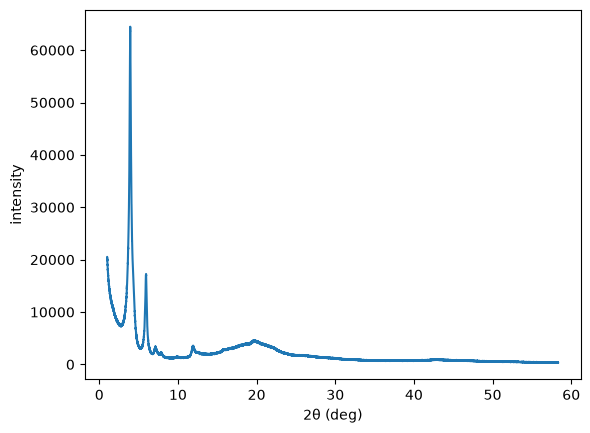

In [4]:
plt.plot(data.tt(), data.y())
plt.xlabel("2θ (deg)")
plt.ylabel("intensity")
plt.show()

adding a model for our instrument - which we know is a flat plate transmission with Cu Kalpha radiation

In [5]:
instrument = rx.Instrument.flat_plate_transmission(radiation= "CuKa")
instrument.background = BackgroundChebyshev.with_terms(5) # adding a background function

#quickly reading out properties of our instrument 
for item in instrument:
    for sub in item:
        print(sub)

source
kind='xray_cw' lines=[EmissionLine(wavelength=Parameter(value=1.5405929, vary=False, min=0.001, max=inf, expr=None, transform='identity', unit='A', stderr=None), weight=Parameter(value=1.0, vary=False, min=0.0, max=2.0, expr=None, transform='identity', unit=None, stderr=None)), EmissionLine(wavelength=Parameter(value=1.5444274, vary=False, min=0.001, max=inf, expr=None, transform='identity', unit='A', stderr=None), weight=Parameter(value=0.5, vary=False, min=0.0, max=1.0, expr=None, transform='identity', unit=None, stderr=None))] polarization=Parameter(value=0.5, vary=False, min=0.0, max=1.0, expr=None, transform='identity', unit=None, stderr=None) dispersion=Dispersion(table='cromer_liberman', overrides={}) harmonics=[]
geometry
kind='flat_plate_transmission' goniometer_radius_mm=None surface_roughness=None sample_displacement=Parameter(value=0.0, vary=False, min=-1.0, max=1.0, expr=None, transform='identity', unit='mm', stderr=None) sample_transparency=Parameter(value=0.0, var

Adding the structural information about the model from a cif file

In [6]:
structure = rx.Structure.from_cif("Phos-COF-1_AA_P-3_rev-vdW-DF2.cif")

#this simply gives a name to the phase for plotting
phase = structure.phases[0] 
phase.name = "PhosCof" 

#check that your cif read in right - the unit cell information is important for us - the atoms not as much right now
print(f"phase: {phase.name}, {phase.space_group}, a={phase.cell.a.value} A, b = {phase.cell.b.value} A, c = {phase.cell.c.value} A "
      f"{len(phase.atoms)} asymmetric atoms")

phase: PhosCof, P -3, a=31.2823203127 A, b = 31.2823203127 A, c = 4.0027 A 19 asymmetric atoms


Running a refinement using the refinement object

In [7]:
ref = rx.Refinement(structure= structure, instrument = instrument)


Running a Le Bail fit

In [8]:
lebail = ref.fit(data, mode = 'lebail')


Seeing the results of your fit and looking at the statistics

In [ ]:


a_lb = ref.fitted_structure.phases[0].cell.a.value
b_lb = ref.fitted_structure.phases[0].cell.b.value
c_lb = ref.fitted_structure.phases[0].cell.c.value


print(f"\nLe Bail:  status={lebail.status}  Rwp={lebail.statistics.rwp:.4f}  "
      f"GoF={lebail.statistics.gof:.2f}  a={a_lb:.6f} A b={b_lb} A c={c_lb} A ")



print(lebail)


Le Bail:  status=converged  Rwp=0.3550  GoF=17.48  a=31.388578 A b=31.388577877333706 A c=4.02645086973081 A 
RefinementResult: converged (lebail)
  stage bkg: converged (14 it, ftol=1e-06)
  stage zero: max_iter (400 it, ftol=1e-06)
  stage cell: max_iter (400 it, ftol=1e-06)
  stage profile_w: converged (11 it, ftol=1e-06)
  stage profile: converged (17 it, ftol=solver default), max|Δθ|/esd=0.000
  diagnostics: 5 unresolved
    WARNING BOUND_HIT: instrument.zero_shift refined to its bound — widen the bound or fix the parameter
    WARNING BOUND_HIT: instrument.profile.u refined to its bound — widen the bound or fix the parameter
    WARNING BOUND_HIT: instrument.profile.v refined to its bound — widen the bound or fix the parameter
    WARNING STAGE_MAX_ITER: stage 'zero', 'cell' stopped on their iteration budgets rather than converging — the parameters freed there are probably degenerate (the agent skill §3) rather than merely slow: free fewer at once, or check the diagnostics for a

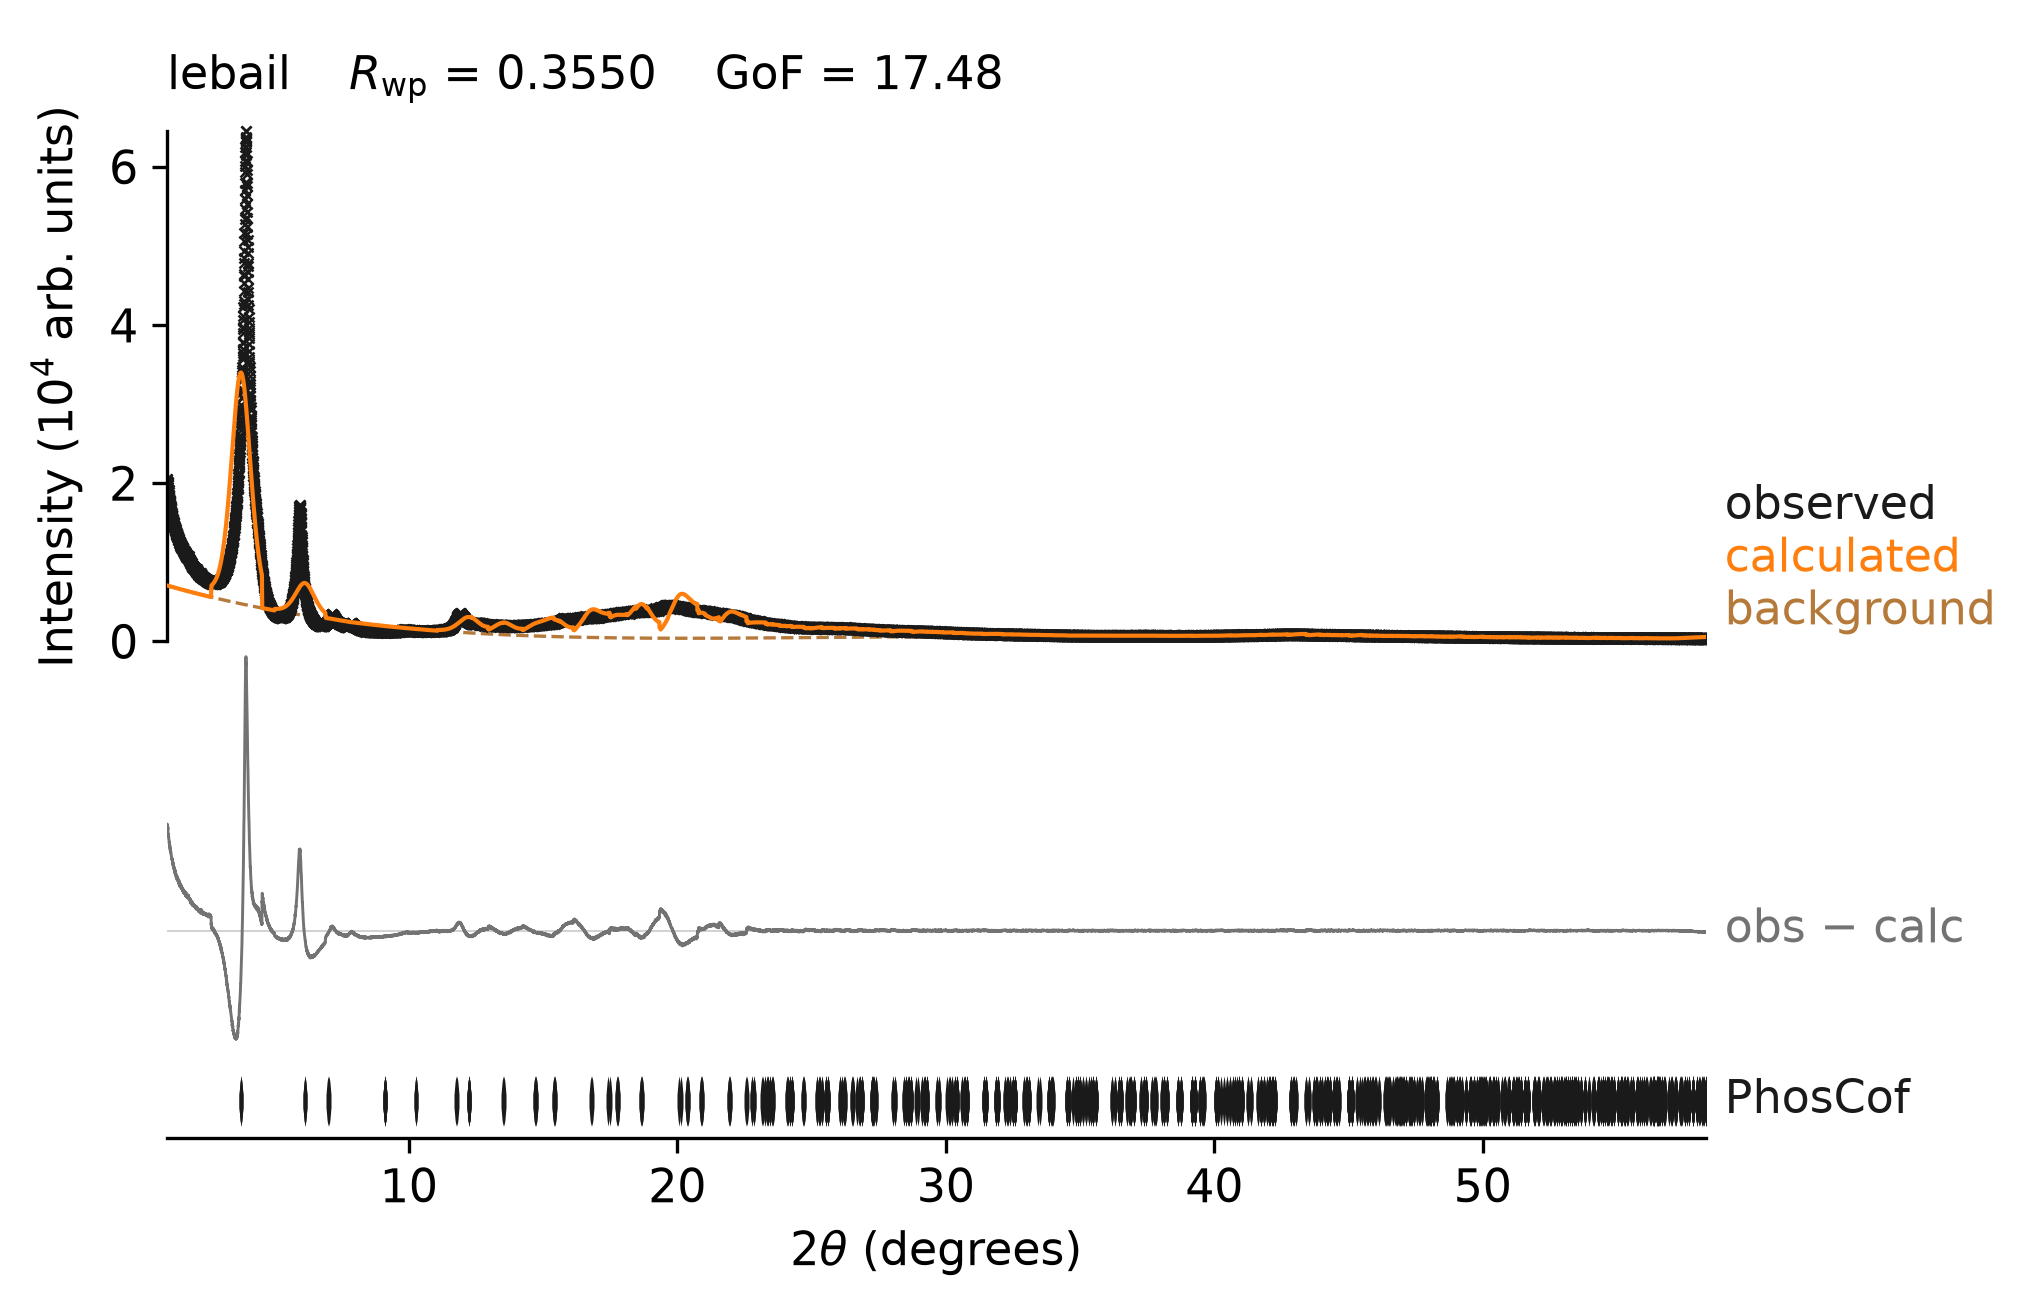

In [17]:
lebail.plot(path = "COF.png")